<a href="https://colab.research.google.com/github/wongihun/natural-language/blob/main/RNN_%ED%99%9C%EC%9A%A9_%EC%B1%97%EB%B4%87%EC%9D%98_%EC%82%AC%EB%B3%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##1. RNN 기반 의도(Intent) 분류 챗봇
단순히 사용자의 의도(긍정/부정)을 판단하고, 이를 통해 각 경우에 따른 답변을 주는 챗봇

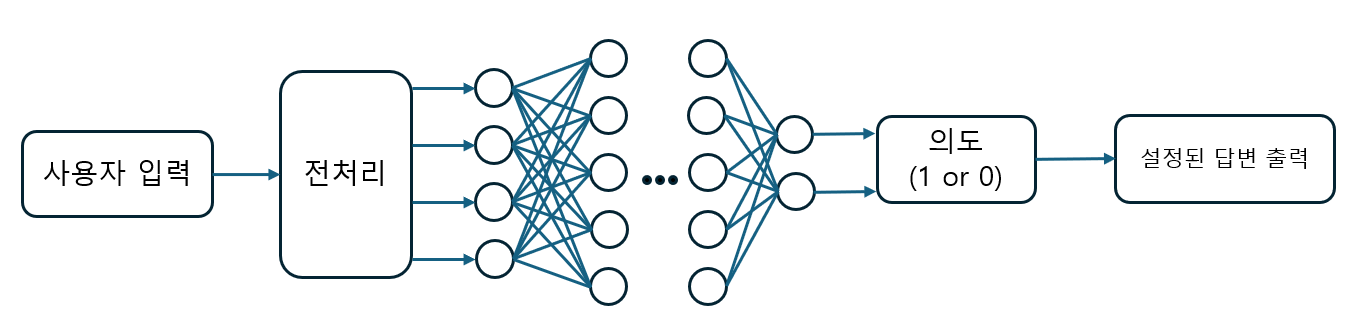
※ 0 : 긍정
1 : 부정

In [ ]:
# 형태소 분석기 활용을 위한 라이브러리 설치
!pip install konlpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 45.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 438.5/438.5 kB 13.5 MB/s eta 0:00:00


In [ ]:
import numpy as np

from konlpy.tag import Okt

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences #문장의 크기가 각각 다른 경우, 짧은 문장에 대한 padding

# 인공지능 모델 구성을 위한 라이브러리
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

#데이터 조작을 위한 라이브러리
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical


In [ ]:
texts = [

    # =========================
    # 긍정
    # =========================
    "오늘 하루 좋았어요",
    "오늘 정말 좋았어요",
    "기분이 좋았어요",
    "하루가 좋았어요",
    "오늘 하루 행복했어요",
    "오늘 하루가 정말 즐거웠어요",
    "기분이 아주 좋아요",
    "정말 행복한 하루입니다",
    "시험 결과가 만족스러워요",
    "오늘은 최고의 날이에요",
    "웃음이 계속 나와요",
    "너무 신나는 하루였어요",
    "정말 재미있었어요",
    "모든 일이 잘 풀렸어요",
    "오늘 컨디션이 최고예요",
    "마음이 편안해졌어요",
    "행복해서 기분이 좋아요",
    "정말 감사한 마음입니다",
    "오늘은 운이 좋은 날이에요",
    "좋은 일이 계속 생기고 있어요",
    "정말 뿌듯한 하루였습니다",
    "너무 만족스러워요",
    "오늘 하루가 완벽했어요",
    "즐거운 시간을 보냈어요",
    "행복한 기분이 들어요",
    "기분 좋게 하루를 시작했어요",
    "오늘은 모든 게 잘 됐어요",
    "친구들과 즐거운 시간을 보냈어요",
    "정말 멋진 경험이었어요",
    "너무 기분 좋은 하루입니다",
    "마음이 따뜻해졌어요",
    "오늘은 특별히 행복해요",
    "웃을 일이 많았어요",
    "정말 좋은 하루였어요",
    "모든 게 만족스러워요",
    "행복한 일이 생겼어요",
    "오늘은 기분이 상쾌해요",
    "재미있는 일이 많았어요",
    "오늘 하루가 소중하게 느껴져요",
    "너무 즐거웠습니다",
    "마음이 한결 가벼워졌어요",
    "오늘은 좋은 소식이 많았어요",
    "정말 신나는 하루였어요",
    "행복한 기억이 생겼어요",
    "오늘은 웃음이 끊이지 않았어요",
    "기분이 매우 좋아졌어요",
    "좋은 사람들과 함께했어요",
    "오늘 하루가 뜻깊었어요",
    "정말 만족스러운 결과예요",
    "즐거운 하루를 보냈습니다",
    "행복한 순간이 많았어요",
    "오늘은 모든 게 행복해 보여요",
    "정말 기쁜 하루입니다",
    "좋은 결과를 얻어서 행복해요",
    "오늘은 평소보다 더 즐거워요",
    "너무 감사한 하루였어요",
    "마음이 편안하고 좋아요",
    "정말 행복한 순간입니다",
    "오늘 하루가 기대 이상이었어요",
    "기분 좋게 웃을 수 있었어요",
    "오늘은 모든 일이 순조로웠어요",
    "행복한 감정이 가득해요",
    "좋은 기운이 느껴져요",
    "정말 설레는 하루였어요",
    "오늘은 웃음이 많았어요",
    "너무 좋은 경험이었어요",
    "행복한 생각이 들어요",
    "오늘은 즐거운 하루입니다",
    "정말 만족스럽게 끝났어요",
    "오늘 하루가 아름다웠어요",
    "행복한 분위기였어요",
    "좋은 일이 생겨서 기뻐요",
    "오늘은 마음이 안정돼요",
    "즐거운 기억으로 남을 것 같아요",
    "정말 행복해서 웃음이 나와요",
    "오늘 하루가 환상적이었어요",
    "기분이 맑아진 느낌이에요",
    "좋은 하루를 보내고 있어요",
    "오늘은 정말 신났어요",
    "행복함이 느껴집니다",
    "오늘은 기분이 밝아요",
    "즐거운 소식이 들려왔어요",
    "정말 보람찬 하루였어요",
    "오늘 하루가 성공적이었어요",
    "좋은 시간을 보내서 행복해요",
    "마음이 따뜻한 하루였어요",
    "오늘은 만족감이 커요",
    "행복한 일이 계속 이어져요",
    "정말 즐거운 시간이었어요",
    "오늘 하루가 기분 좋게 끝났어요",
    "좋은 결과라서 기뻐요",
    "오늘은 활력이 넘쳐요",
    "행복한 감정으로 가득해요",
    "모든 게 잘되어서 좋아요",
    "오늘은 아주 행복합니다",
    "즐겁고 유쾌한 하루였어요",
    "기분이 정말 상쾌해요",
    "오늘은 기쁜 일이 많았어요",
    "행복하게 하루를 보냈어요",
    "행복한 하루라서 좋아요",
    "오늘 하루가 인상 깊었어요",
    "좋은 사람들과 함께해서 행복해요",
    "정말 밝은 하루였습니다",
    "오늘은 마음이 풍요로워요",
    "기분 좋게 하루를 마무리했어요",

    # =========================
    # 부정
    # =========================

    "오늘 너무 피곤해요",
    "기분이 우울합니다",
    "정말 힘든 하루였어요",
    "시험 결과가 실망스러워요",
    "짜증나는 일이 많았어요",
    "스트레스를 많이 받고 있어요",
    "몸 상태가 좋지 않아요",
    "오늘은 아무것도 하기 싫어요",
    "계속 우울한 기분이에요",
    "실패해서 속상합니다",
    "정말 화가 나요",
    "너무 지치고 힘들어요",
    "오늘 일이 잘 안 풀려요",
    "모든 게 귀찮아요",
    "기분이 많이 다운됐어요",
    "계속 걱정이 됩니다",
    "마음이 답답해요",
    "정말 실망했습니다",
    "아무 의욕이 없어요",
    "너무 속상하고 슬퍼요",
    "오늘 하루가 너무 힘들었어요",
    "기분이 좋지 않습니다",
    "정말 피곤한 하루였어요",
    "스트레스가 심해요",
    "짜증이 계속 나요",
    "오늘은 되는 일이 없어요",
    "마음이 너무 무거워요",
    "우울한 기분이 들어요",
    "너무 힘이 빠져요",
    "오늘 하루가 지루했어요",
    "계속 피곤한 상태예요",
    "정말 속상한 일이 있었어요",
    "모든 게 불안하게 느껴져요",
    "오늘은 우울한 날이에요",
    "마음이 복잡하고 답답해요",
    "정말 화나는 하루였어요",
    "계속 실수해서 속상해요",
    "기분이 너무 가라앉았어요",
    "오늘은 기운이 없어요",
    "너무 지쳐서 쉬고 싶어요",
    "걱정이 계속 머릿속에 맴돌아요",
    "오늘 하루가 최악이었어요",
    "정말 피곤하고 우울해요",
    "마음이 힘들어요",
    "모든 게 부담스럽게 느껴져요",
    "오늘은 너무 답답했어요",
    "기분이 계속 안 좋아요",
    "정말 속상한 하루였습니다",
    "오늘은 웃을 일이 없었어요",
    "너무 피곤해서 아무것도 못 하겠어요",
    "마음이 우울하고 무거워요",
    "오늘은 의욕이 전혀 없어요",
    "계속 스트레스만 쌓여요",
    "정말 슬픈 기분입니다",
    "오늘은 많이 지쳤어요",
    "너무 힘든 일이 많았어요",
    "기분이 자꾸 나빠져요",
    "마음이 불편해요",
    "오늘 하루가 너무 길게 느껴졌어요",
    "정말 실망스러운 결과예요",
    "오늘은 최악의 하루예요",
    "계속 짜증이 나고 힘들어요",
    "기분이 좋을 이유가 없어요",
    "너무 피곤해서 집중이 안 돼요",
    "오늘은 모든 게 귀찮아요",
    "정말 우울한 상태입니다",
    "마음이 계속 불안해요",
    "오늘 하루가 힘겹게 느껴져요",
    "너무 답답하고 화가 나요",
    "계속 부정적인 생각이 들어요",
    "오늘은 쉬고만 싶어요",
    "정말 피로가 심해요",
    "모든 게 마음에 안 들어요",
    "오늘은 너무 지루했어요",
    "기분이 계속 처져 있어요",
    "정말 괴로운 하루였습니다",
    "계속 한숨만 나와요",
    "오늘은 아무 의미 없는 하루 같아요",
    "너무 우울해서 힘들어요",
    "마음이 무겁고 답답합니다",
    "오늘은 집중이 잘 안 돼요",
    "계속 불안한 느낌이 들어요",
    "정말 화나는 일이 있었어요",
    "오늘 하루가 너무 고단했어요",
    "기분이 엉망이에요",
    "너무 스트레스 받아요",
    "오늘은 정말 피곤하네요",
    "계속 슬픈 생각이 들어요",
    "마음이 쉽게 진정되지 않아요",
    "오늘은 모든 게 힘들어요",
    "정말 짜증나는 하루였어요",
    "계속 기운이 없어요",
    "너무 우울한 상태입니다",
    "오늘은 아무것도 하기 싫네요",
    "마음이 지쳐 있어요",
    "정말 힘빠지는 하루였어요",
    "오늘은 우울감이 심해요",
    "계속 스트레스가 쌓이고 있어요",
    "정말 괴로운 기분입니다",
    "오늘 하루가 너무 버거웠어요",
]

In [ ]:
#긍정형 문장 : 105개
#부정형 문장 : 100개
print(len(texts))

205


In [ ]:
labels = (

    # 긍정 = 0
    [0] * 105 +

    # 부정 = 1
    [1] * 100
)

In [ ]:
#전처리기 : kiwi
!pip install kiwipiepy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 9.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 19.4 MB/s eta 0:00:00
  Created wheel for kiwipiepy_model: filename=kiwipiepy_model-0.23.0-py3-none-any.whl size=88067826 sha256=03f1d0f329a88eeeb0823c2fd59340a0b6b7fd7adbe799d94078f7c163828691
  Stored in directory: /root/.cache/pip/wheels/f2/94/da/ff88b4c2305cd1f3effc8001b5f42f16dc9931bcd84d1e77c3
Successfully built kiwipiepy_model


In [ ]:
from kiwipiepy import Kiwi

kiwi = Kiwi()

def morph_tokenizer(text):
    buf = []
    tokens = kiwi.tokenize(text)
    for token in tokens:
        if token.tag.startswith('J') or token.tag.startswith('S') or token.tag.startswith('E'):
            continue
        buf.append(token.form)
    return buf

In [ ]:
processed_texts = []

for text in texts:
    morphs = morph_tokenizer(text)
    joined = " ".join(morphs)
    processed_texts.append(joined)

In [ ]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(processed_texts)

X = tokenizer.texts_to_sequences(processed_texts)

# 문장 길이 맞추기
X = pad_sequences(X, maxlen=15)

# One-Hot Encoding
y = to_categorical(labels, num_classes=2)

vocab_size = len(tokenizer.word_index) + 1


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
model = Sequential()

# 임베딩
model.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=64,
        input_length=15
    )
)

# 순수 RNN
model.add(
    SimpleRNN(128, dropout=0.2)
)

# 출력층
model.add(
    Dense(2, activation='softmax')
)

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [ ]:
model.fit(
    X_train,
    y_train,
    epochs=300,
    batch_size=8,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/300
17/17 ━━━━━━━━━━━━━━━━━━━━ 6s 77ms/step - accuracy: 0.4351 - loss: 0.7199 - val_accuracy: 0.6970 - val_loss: 0.6565
Epoch 2/300
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.6565 - loss: 0.6412 - val_accuracy: 0.7576 - val_loss: 0.6311
Epoch 3/300
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.8779 - loss: 0.5486 - val_accuracy: 0.7273 - val_loss: 0.5670
Epoch 4/300
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8855 - loss: 0.4192 - val_accuracy: 0.7273 - val_loss: 0.5359
Epoch 5/300
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9160 - loss: 0.2808 - val_accuracy: 0.7273 - val_loss: 0.4412
Epoch 6/300
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9847 - loss: 0.1389 - val_accuracy: 0.7273 - val_loss: 0.4058
Epoch 7/300
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9847 - loss: 0.0849 - val_accuracy: 0.8485 - val_loss: 0.4177
Epoch 8/300
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9847 - loss: 0.0692 - val_accuracy: 0.

In [ ]:
loss, acc = model.evaluate(X_test, y_test)

print("\n테스트 정확도 :", acc)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - accuracy: 0.8780 - loss: 0.4322

테스트 정확도 : 0.8780487775802612


In [ ]:
response_dict = {

    # 긍정
    0: [
        "좋은 하루네요 😊",
        "기분이 좋아 보이네요 😊",
        "행복해 보여요 😊"
    ],

    # 부정
    1: [
        "많이 힘드셨겠어요 😥",
        "오늘은 푹 쉬세요 😥",
        "속상하셨겠어요 😥"
    ]
}

In [ ]:
def chatbot(sentence):

    # 형태소 분석
    morphs = morph_tokenizer(sentence)

    joined = " ".join(morphs)

    # 정수 변환
    seq = tokenizer.texts_to_sequences(
        [joined]
    )

    # 패딩
    padded = pad_sequences(
        seq,
        maxlen=15
    )

    # 예측
    pred = model.predict(
        padded,
        verbose=0
    )

    intent = np.argmax(pred)

    # 랜덤 응답
    import random

    response = random.choice(
        response_dict[intent]
    )

    print("\n사용자 :", sentence)
    print("형태소 :", morphs)
    print("예측 의도 :", intent)
    print("챗봇 :", response)


In [ ]:
while True:

    user_input = input("\n사용자 입력 : ")

    if user_input == "종료":
        break

    chatbot(user_input)


사용자 입력 : 너무 힘들다

사용자 : 너무 힘들다
형태소 : ['너무', '힘들']
예측 의도 : 1
챗봇 : 많이 힘드셨겠어요 😥

사용자 입력 : 오늘 너무 힘들었다

사용자 : 오늘 너무 힘들었다
형태소 : ['오늘', '너무', '힘들']
예측 의도 : 1
챗봇 : 많이 힘드셨겠어요 😥

사용자 입력 : 종료


##2. 생성형 기반 RNN 챗봇

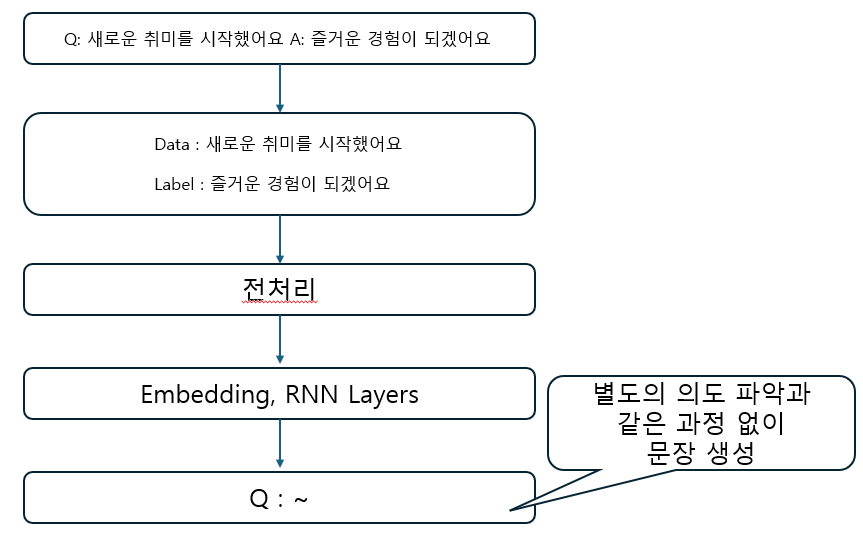

- 위의 의도 파악과는 다르게 지정된 답변이 아닌, 답변 자체가 생성되는 방식
- 이전 예측 데이터를 활용하는 RNN 의 특징 중 전체 결과를 활용하는 방안을 채택

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, RepeatVector, TimeDistributed
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

import numpy as np

In [ ]:
dataset = [
    "Q: 오늘 친구와 즐거운 시간을 보냈어요 A: 좋은 추억을 만드셨군요",
    "Q: 오랜만에 가족을 만나서 행복했어요 A: 가족과의 시간은 소중하죠",
    "Q: 좋아하는 음식을 먹었어요 A: 만족스러운 식사였겠네요",
    "Q: 운동을 하고 나니 상쾌해요 A: 건강한 하루를 보내셨군요",
    "Q: 오늘 칭찬을 받았어요 A: 기분 좋은 일이 있었네요",
    "Q: 새로운 취미를 시작했어요 A: 즐거운 경험이 되겠어요",
    "Q: 목표를 달성해서 뿌듯해요 A: 노력의 결실을 맺으셨군요",
    "Q: 좋은 소식을 들었어요 A: 정말 기쁜 일이네요",
    "Q: 여행 계획을 세우고 있어요 A: 설레는 시간이 되겠어요",
    "Q: 오늘 날씨가 정말 좋네요 A: 기분까지 좋아지는 날씨예요",

    "Q: 프로젝트를 성공적으로 마쳤어요 A: 수고하신 만큼 좋은 결과네요",
    "Q: 시험에 합격했어요 A: 진심으로 축하드려요",
    "Q: 새로운 친구를 사귀었어요 A: 좋은 인연이 되길 바라요",
    "Q: 책 한 권을 다 읽었어요 A: 의미 있는 시간을 보내셨네요",
    "Q: 오늘 일이 순조롭게 풀렸어요 A: 만족스러운 하루였겠어요",
    "Q: 월급을 받아서 기분이 좋아요 A: 보람을 느끼셨겠네요",
    "Q: 원하는 물건을 샀어요 A: 오랫동안 기억에 남겠어요",
    "Q: 오늘 많이 웃었어요 A: 즐거운 하루를 보내셨군요",
    "Q: 산책을 했더니 기분이 좋아졌어요 A: 좋은 휴식이 되었겠네요",
    "Q: 공연을 보고 감동받았어요 A: 특별한 경험을 하셨군요",

    "Q: 오늘 너무 졸려요 A: 충분한 휴식이 필요해 보이네요",
    "Q: 일이 너무 많아서 힘들어요 A: 부담이 크셨겠어요",
    "Q: 실수를 해서 속상해요 A: 누구나 실수할 수 있어요",
    "Q: 친구와 다퉜어요 A: 마음이 많이 불편하시겠네요",
    "Q: 계획대로 되지 않았어요 A: 아쉬움이 남는 하루였겠어요",
    "Q: 몸이 좋지 않아요 A: 건강을 잘 챙기셔야겠어요",
    "Q: 스트레스를 많이 받고 있어요 A: 잠시 쉬어가는 것도 필요해요",
    "Q: 오늘 집중이 잘 안 돼요 A: 컨디션이 좋지 않은가 보네요",
    "Q: 기대했던 결과가 아니에요 A: 실망이 크셨겠어요",
    "Q: 너무 바빠서 지쳐요 A: 충분히 쉬는 시간을 가져보세요",

    "Q: 비가 와서 우울해요 A: 날씨 때문에 기분이 가라앉을 수 있죠",
    "Q: 약속이 취소됐어요 A: 아쉬운 마음이 드셨겠네요",
    "Q: 시험을 망친 것 같아요 A: 많이 걱정되시겠어요",
    "Q: 중요한 일을 깜빡했어요 A: 당황스러우셨겠네요",
    "Q: 오늘 운이 안 좋은 것 같아요 A: 그런 날도 있는 법이죠",
    "Q: 피드백이 좋지 않았어요 A: 속상한 마음이 드셨겠어요",
    "Q: 잠을 제대로 못 잤어요 A: 많이 피곤하시겠네요",
    "Q: 해야 할 일이 산더미예요 A: 하나씩 차근차근 해결해 보세요",
    "Q: 실연을 당했어요 A: 마음이 많이 아프시겠어요",
    "Q: 기대했던 연락이 오지 않았어요 A: 답답한 마음이 드시겠네요",

    "Q: 오늘 새로운 것을 배웠어요 A: 뜻깊은 하루를 보내셨군요",
    "Q: 봉사활동을 하고 왔어요 A: 따뜻한 마음이 느껴지네요",
    "Q: 저축 목표를 달성했어요 A: 계획을 잘 실천하셨네요",
    "Q: 좋아하는 노래를 들었어요 A: 기분 전환이 되었겠어요",
    "Q: 방을 깨끗하게 정리했어요 A: 한결 상쾌해졌겠네요",
    "Q: 맛있는 커피를 마셨어요 A: 작은 행복을 느끼셨군요",
    "Q: 오늘 일찍 퇴근했어요 A: 여유로운 시간을 보내실 수 있겠네요",
    "Q: 좋은 영화를 봤어요 A: 인상 깊은 시간이었겠어요",
    "Q: 반려동물과 놀아줬어요 A: 즐거운 시간을 보내셨네요",
    "Q: 오늘 목표한 공부를 끝냈어요 A: 스스로가 자랑스러우시겠어요"
]

In [ ]:
# Q, A 로 각각 분리
# Q: 오늘 새로운 것을 배웠어요 A: 뜻깊은 하루를 보내셨군요
# → Q: 오늘 새로운 것을 배웠어요 /  A: 뜻깊은 하루를 보내셨군요
questions = []
answers = []

for row in dataset:

    q = row.split("A:")[0]
    a = row.split("A:")[1]

    q = q.replace("Q:", "").strip()
    a = a.strip()

    answers.append(a)
    questions.append(q)

In [ ]:
# filters : 특수문자 제거 옵션
# 현재 : 제거 하지 않음
tokenizer = Tokenizer(
    filters=''
)

# 답변을 위한 단어 사전 생성
# 단어 사전은 요청, 답변의 모든 단어를 학습한다.
tokenizer.fit_on_texts(
    questions + answers
)

# PAD(1) + 응답,입력 데이터
vocab_size = len(tokenizer.word_index) + 1

In [ ]:
# 단어 사전에 대응되는 각 토큰에 따른 변환 수행
question_seq = tokenizer.texts_to_sequences(
    questions
)

answer_seq = tokenizer.texts_to_sequences(
    answers
)

In [ ]:
#제일 긴 문장 탐색
max_question_len = max(
    len(seq)
    for seq in question_seq
)

max_answer_len = max(
    len(seq)
    for seq in answer_seq
)


In [ ]:
#각 학습 데이터에 대한 패딩 적용

X = pad_sequences(
    question_seq,
    maxlen=max_question_len,
    padding='post'
)

y = pad_sequences(
    answer_seq,
    maxlen=max_answer_len,
    padding='post'
)

In [ ]:
model = Sequential()

# Encoder
model.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=64
    )
)

# RNN : 문장의 이해
model.add(
    SimpleRNN(
        128
    )
)

# Decoder
# "답변을 몇 단어까지 만들지"에 맞춰 질문의 의미(Context Vector)를 여러 개로 복제
model.add(
    RepeatVector(
        max_answer_len
    )
)

#RNN : 문장의 생성
model.add(
    SimpleRNN(
        128,
        return_sequences=True
    )
)

#위층에서 생성된 벡터를 단어 확률로 변환
#가장 높은 확률의 단어를 선택
model.add(
    TimeDistributed(
        Dense(
            vocab_size,
            activation='softmax'
        )
    )
)

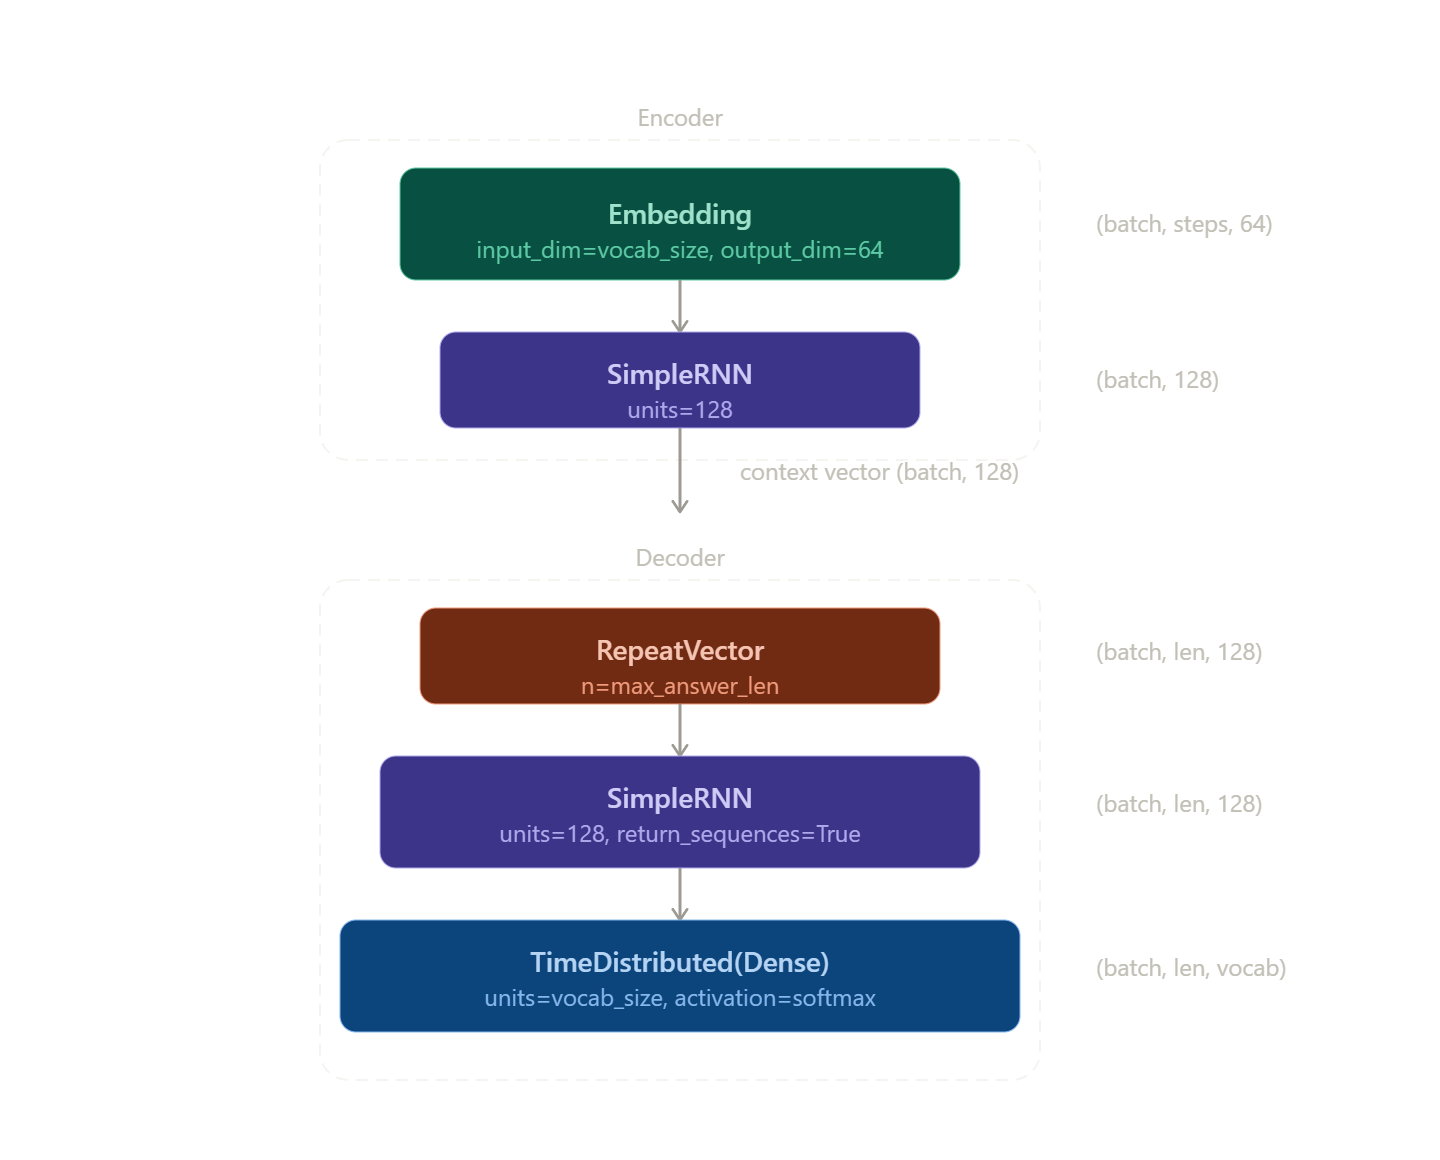

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


model.fit(
    X,
    y,
    epochs=200,
    callbacks=[early_stop],
    verbose=1
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ ?                      │   0 (unbuilt) │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.0800 - loss: 5.4632
Epoch 2/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.4800 - loss: 5.1167
Epoch 3/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.4867 - loss: 4.5737
Epoch 4/200
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.4583 - loss: 4.1436

/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.4867 - loss: 3.9765
Epoch 5/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.4867 - loss: 3.5448
Epoch 6/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.4867 - loss: 3.2496
Epoch 7/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.4867 - loss: 3.0962
Epoch 8/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.4867 - loss: 3.0495
Epoch 9/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.4867 - loss: 3.0036
Epoch 10/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.4867 - loss: 2.9307
Epoch 11/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.4867 - loss: 2.8533
Epoch 12/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.4867 - loss: 2.7913
Epoch 13/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.4867 - loss: 2.7299
Epoch 14/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.4867 - loss: 2.6665
Epoch 15/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.4867 - loss: 2.621

In [ ]:
#역변환 단어사전
idx2word = {}

for word, idx in tokenizer.word_index.items():
    idx2word[idx] = word

In [ ]:
def chatbot(text):

    # 입력 데이터에 대한 전처리 및 모델 예측 수행
    seq = tokenizer.texts_to_sequences(
        [text]
    )

    seq = pad_sequences(
        seq,
        maxlen=max_question_len,
        padding='post'
    )

    #예측
    pred = model.predict(
        seq,
        verbose=0
    )

    # 출력된 벡터 중 가장 확률이 높은 벡터 선택
    pred_ids = np.argmax(
        pred,
        axis=-1
    )[0]

    result = []

    # 역변환 단어사전 전환 수행
    for idx in pred_ids:

        if idx == 0:
            continue

        word = idx2word.get(idx)

        result.append(word)

    return " ".join(result)

In [ ]:
while True:

    text = input("사용자 : ")

    if text == "종료":
        break

    output = chatbot(text)
    print(
        "챗봇 :",
        output
    )

챗봇 : 즐거운 많이


---
- 학습 데이터의 부족(어색한 문장 내용)
- 일부 데이터의 단어 반복 현상(RNN의 문제-단순 단어 패턴 파악)
→ 문장의 경우 앞뒤 또는 전체 문맥에 따라 답변이 필요
